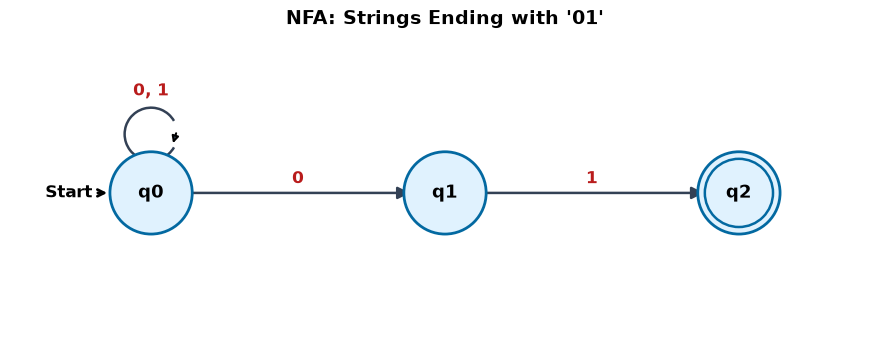


--- Simulation Result ---
Input string : 1001
Active Sets  : {q0} -> {q0} -> {q0, q1} -> {q0, q1} -> {q0, q2}
Status       : ACCEPTED ✅


In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np


class NFA:

  def __init__(
      self, states, alphabet, transition_function, start_state, accept_states
  ):
    self.states = list(states)
    self.alphabet = set(alphabet)
    self.transition_function = transition_function
    self.start_state = start_state
    self.accept_states = set(accept_states)

  def trace(self, input_string):
    """Tracks all active state sets step-by-step for a given input."""
    current_states = {self.start_state}
    path_history = [set(current_states)]

    for symbol in input_string:
      if symbol not in self.alphabet:
        return False, path_history

      next_states = set()
      for state in current_states:
        if (
            state in self.transition_function
            and symbol in self.transition_function[state]
        ):
          next_states.update(self.transition_function[state][symbol])

      current_states = next_states
      path_history.append(set(current_states))

    is_accepted = any(state in self.accept_states for state in current_states)
    return is_accepted, path_history

  def visualize_matplotlib(self, test_string=None):
    fig, ax = plt.subplots(figsize=(9, 4.5))

    # Node positions
    pos = {
        "q0": np.array([1.0, 2.0]),
        "q1": np.array([3.5, 2.0]),
        "q2": np.array([6.0, 2.0]),
    }
    r = 0.35  # Node radius

    # 1. Draw States
    for state, (x, y) in pos.items():
      # Base state circle
      circle = plt.Circle(
          (x, y),
          r,
          facecolor="#e0f2fe",
          edgecolor="#0369a1",
          linewidth=2,
          zorder=3,
      )
      ax.add_patch(circle)

      # Accept State Inner Ring (Double Circle)
      if state in self.accept_states:
        inner_circle = plt.Circle(
            (x, y),
            r - 0.06,
            facecolor="#e0f2fe",
            edgecolor="#0369a1",
            linewidth=1.8,
            zorder=4,
        )
        ax.add_patch(inner_circle)

      # State Label
      ax.text(
          x,
          y,
          state,
          ha="center",
          va="center",
          fontsize=13,
          fontweight="bold",
          zorder=5,
      )

    # 2. Start State Indicator Arrow
    sx, sy = pos[self.start_state]
    ax.annotate(
        "Start",
        xy=(sx - r, sy),
        xytext=(sx - 0.9, sy),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=2),
        fontsize=12,
        fontweight="bold",
        va="center",
    )

    # 3. Transitions (q0 -> q1 on '0', q1 -> q2 on '1')
    transitions_to_draw = [
        ("q0", "q1", "0", 0.0, 0.12),
        ("q1", "q2", "1", 0.0, 0.12),
    ]

    for src, dst, label, rad, lbl_off in transitions_to_draw:
      p1 = pos[src]
      p2 = pos[dst]

      arrow = patches.FancyArrowPatch(
          posA=(p1[0], p1[1]),
          posB=(p2[0], p2[1]),
          connectionstyle=f"arc3,rad={rad}",
          arrowstyle="-|>",
          mutation_scale=18,
          color="#334155",
          lw=1.8,
          shrinkA=r * 72,
          shrinkB=r * 72,
          zorder=2,
      )
      ax.add_patch(arrow)

      mid_x = (p1[0] + p2[0]) / 2
      mid_y = (p1[1] + p2[1]) / 2 + lbl_off
      ax.text(
          mid_x,
          mid_y,
          label,
          fontsize=12,
          fontweight="bold",
          color="#b91c1c",
          ha="center",
          va="center",
          bbox=dict(
              boxstyle="round,pad=0.2",
              facecolor="white",
              edgecolor="none",
              alpha=0.8,
          ),
      )

    # 4. Self-Loop on q0 (for '0, 1')
    x, y = pos["q0"]
    loop = patches.Arc(
        (x, y + r + 0.15),
        0.45,
        0.45,
        angle=0,
        theta1=30,
        theta2=330,
        color="#334155",
        lw=1.8,
    )
    ax.add_patch(loop)

    ax.annotate(
        "",
        xy=(x + 0.18, y + r + 0.05),
        xytext=(x + 0.22, y + r + 0.18),
        arrowprops=dict(facecolor="#334155", arrowstyle="-|>", lw=1.5),
    )

    ax.text(
        x,
        y + r + 0.48,
        "0, 1",
        fontsize=12,
        fontweight="bold",
        color="#b91c1c",
        ha="center",
    )

    ax.set_xlim(-0.2, 7.2)
    ax.set_ylim(0.8, 3.2)
    ax.set_aspect("equal")
    plt.title(
        "NFA: Strings Ending with '01'", fontsize=14, fontweight="bold", pad=20
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # Optional Trace Execution
    if test_string is not None:
      accepted, path = self.trace(test_string)
      verdict = "ACCEPTED ✅" if accepted else "REJECTED ❌"
      formatted_path = " -> ".join(
          [f"{{{', '.join(sorted(s))}}}" if s else "∅" for s in path]
      )
      print(f"\n--- Simulation Result ---")
      print(f"Input string : {test_string}")
      print(f"Active Sets  : {formatted_path}")
      print(f"Status       : {verdict}")


# --- Execution ---
states = {"q0", "q1", "q2"}
alphabet = {"0", "1"}
start_state = "q0"
accept_states = {"q2"}

# NFA transition table mapping (state, symbol) -> set of target states
transitions = {
    "q0": {"0": {"q0", "q1"}, "1": {"q0"}},
    "q1": {"1": {"q2"}},
    "q2": {},
}

nfa = NFA(states, alphabet, transitions, start_state, accept_states)
nfa.visualize_matplotlib(test_string="1001")